In [132]:
%pip install matplotlib tqdm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [133]:
import chipwhisperer as cw # You only can use the basic ChipWhisperer functions demonstrated in this basic code
import numpy as np
import random
from tqdm.notebook import trange
import struct
from scipy import stats

# Also the ChipWhisperer provides better plotting functions (based on matplotlib), choose what you prefer
import matplotlib.pyplot as plt

# Initialize ChipWhisperer components
scope = cw.scope()
target = cw.target(scope, cw.targets.SimpleSerial)
scope.default_setup()

# we got 724, so we set it to be a little higher than that(because it depends on the id) 
scope.adc.samples=15000

scope.gain.mode                          changed from low                       to high                     
scope.gain.gain                          changed from 0                         to 30                       
scope.gain.db                            changed from 5.5                       to 24.8359375               
scope.adc.basic_mode                     changed from low                       to rising_edge              
scope.adc.samples                        changed from 24400                     to 5000                     
scope.adc.trig_count                     changed from 1540890                   to 24115001                 
scope.clock.adc_src                      changed from clkgen_x1                 to clkgen_x4                
scope.clock.adc_freq                     changed from 0                         to 29538471                 
scope.clock.adc_rate                     changed from 0.0                       to 29538471.0               
scope.clock.clkgen_

In [218]:
%%bash
make PLATFORM=CWLITEARM SOURCE=c_code.c

No CRYPTO_TARGET passed - defaulting to TINYAES128C
Building for platform CWLITEARM with CRYPTO_TARGET=TINYAES128C
SS_VER set to SS_VER_1_1
SS_VER set to SS_VER_1_1
Blank crypto options, building for AES128
.
Welcome to another exciting ChipWhisperer target build!!
arm-none-eabi-gcc (15:13.2.rel1-2) 13.2.1 20231009
Copyright (C) 2023 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

mkdir -p objdir-CWLITEARM 
.
Compiling:
-en     c_code.c ...
-e Done!
.
Compiling:
-en     ../../firmware/mcu/simpleserial/simpleserial.c ...
-e Done!
.
Compiling:
-en     ../../firmware/mcu/hal/hal.c ...
-e Done!
.
Compiling:
-en     ../../firmware/mcu/hal//stm32f3/stm32f3_hal.c ...
-e Done!
.
Compiling:
-en     ../../firmware/mcu/hal//stm32f3/stm32f3_hal_lowlevel.c ...
-e Done!
.
Compiling:
-en     ../../firmware/mcu/hal//stm32f3/stm32f3_sysmem.c ...
-e Done!
.
Compiling:
-e

/usr/lib/gcc/arm-none-eabi/13.2.1/../../../arm-none-eabi/bin/ld: /usr/lib/gcc/arm-none-eabi/13.2.1/../../../arm-none-eabi/lib/thumb/v7e-m/nofp/libg_nano.a(libc_a-closer.o): in function `_close_r':
/build/newlib-38V0JC/newlib-4.4.0.20231231/build_nano/arm-none-eabi/thumb/v7e-m/nofp/newlib/../../../../../../newlib/libc/reent/closer.c:47:(.text+0xc): warning: _close is not implemented and will always fail
/usr/lib/gcc/arm-none-eabi/13.2.1/../../../arm-none-eabi/bin/ld: /usr/lib/gcc/arm-none-eabi/13.2.1/../../../arm-none-eabi/lib/thumb/v7e-m/nofp/libg_nano.a(libc_a-lseekr.o): in function `_lseek_r':
/build/newlib-38V0JC/newlib-4.4.0.20231231/build_nano/arm-none-eabi/thumb/v7e-m/nofp/newlib/../../../../../../newlib/libc/reent/lseekr.c:49:(.text+0x14): warning: _lseek is not implemented and will always fail
/usr/lib/gcc/arm-none-eabi/13.2.1/../../../arm-none-eabi/bin/ld: /usr/lib/gcc/arm-none-eabi/13.2.1/../../../arm-none-eabi/lib/thumb/v7e-m/nofp/libg_nano.a(libc_a-readr.o): in function `_r

/usr/lib/gcc/arm-none-eabi/13.2.1/../../../arm-none-eabi/bin/ld: /usr/lib/gcc/arm-none-eabi/13.2.1/../../../arm-none-eabi/lib/thumb/v7e-m/nofp/libg_nano.a(libc_a-closer.o): note: the message above does not take linker garbage collection into account
/usr/lib/gcc/arm-none-eabi/13.2.1/../../../arm-none-eabi/bin/ld: /usr/lib/gcc/arm-none-eabi/13.2.1/../../../arm-none-eabi/lib/thumb/v7e-m/nofp/libg_nano.a(libc_a-lseekr.o): note: the message above does not take linker garbage collection into account
/usr/lib/gcc/arm-none-eabi/13.2.1/../../../arm-none-eabi/bin/ld: /usr/lib/gcc/arm-none-eabi/13.2.1/../../../arm-none-eabi/lib/thumb/v7e-m/nofp/libg_nano.a(libc_a-readr.o): note: the message above does not take linker garbage collection into account


/usr/lib/gcc/arm-none-eabi/13.2.1/../../../arm-none-eabi/lib/thumb/v7e-m/nofp/libg_nano.a(libc_a-writer.o): in function `_write_r':
/build/newlib-38V0JC/newlib-4.4.0.20231231/build_nano/arm-none-eabi/thumb/v7e-m/nofp/newlib/../../../../../../newlib/libc/reent/writer.c:49:(.text+0x14): warning: _write is not implemented and will always fail


/usr/lib/gcc/arm-none-eabi/13.2.1/../../../arm-none-eabi/bin/ld: /usr/lib/gcc/arm-none-eabi/13.2.1/../../../arm-none-eabi/lib/thumb/v7e-m/nofp/libg_nano.a(libc_a-writer.o): note: the message above does not take linker garbage collection into account
-e Done!
.
Creating load file for Flash: output-CWLITEARM.hex
arm-none-eabi-objcopy -O ihex -R .eeprom -R .fuse -R .lock -R .signature output-CWLITEARM.elf output-CWLITEARM.hex
.
Creating load file for Flash: output-CWLITEARM.bin
arm-none-eabi-objcopy -O binary -R .eeprom -R .fuse -R .lock -R .signature output-CWLITEARM.elf output-CWLITEARM.bin
.
Creating load file for EEPROM: output-CWLITEARM.eep
arm-none-eabi-objcopy -j .eeprom --set-section-flags=.eeprom="alloc,load" \
--change-section-lma .eeprom=0 --no-change-warnings -O ihex output-CWLITEARM.elf output-CWLITEARM.eep || exit 0
.
Creating Extended Listing: output-CWLITEARM.lss
arm-none-eabi-objdump -h -S -z output-CWLITEARM.elf > output-CWLITEARM.lss
.
Creating Symbol Table: output-CWLI

In [219]:
hex = "output-CWLITEARM.hex"
cw.program_target(scope, cw.programmers.STM32FProgrammer , hex)

Detected known STMF32: STM32F302xB(C)/303xB(C)
Extended erase (0x44), this can take ten seconds or more
Attempting to program 6415 bytes at 0x8000000
STM32F Programming flash...
STM32F Reading flash...
Verified flash OK, 6415 bytes


In [220]:
def execute_trace(command, input_string):
    # Clears any leftover data and arms the scope
    scope.arm()

    # Convert input to bytearray
    if isinstance(input_string, str):
        input_data = bytearray(input_string, 'utf-8')
    else:
        input_data = bytearray(input_string)
        
    # Send the command
    target.simpleserial_write(command, input_data)

    # Capture the trace
    ret = scope.capture()
    if ret:
        raise Exception("Failed to capture trace")

    # Get the trace data
    trace = scope.get_last_trace()
    
    # READ RAW BYTES (Remove the .decode('utf-8'))
    response = target.simpleserial_read('r', 1)
    
    return trace, response

In [221]:
FLAG_HIGH_HW = 1 << 0
FLAG_MASKED = 1 << 1
FLAG_SHUFFLED = 1 << 2

def build_mode_flags(is_high_hw=False, is_masked=False, is_shuffled=False):
    flags = 0
    if is_high_hw:
        flags |= FLAG_HIGH_HW
    if is_masked:
        flags |= FLAG_MASKED
    if is_shuffled:
        flags |= FLAG_SHUFFLED
    return flags

def set_mode_flags(is_high_hw=False, is_masked=False, is_shuffled=False):
    """Set mode flags on target using command 'f'."""
    flags = build_mode_flags(is_high_hw, is_masked, is_shuffled)
    target.simpleserial_write('f', bytearray([flags]))
    response = target.simpleserial_read('r', 1, timeout=100)
    return response


def set_seed(seed_value, is_high_hw=False, is_masked=False, is_shuffled=False, mask_value=0, mask_value2=0, apply_flags=True):
    """
    Sends a 32-bit seed to the unified seed command 's'.
    Payload is 16 bytes: [state(4B), mask1(4B), mask2(4B), shuffle_rng(4B)].
    """
    if apply_flags:
        set_mode_flags(is_high_hw=is_high_hw, is_masked=is_masked, is_shuffled=is_shuffled)

    mask1_32 = int(seed_value) & 0xFFFFFFFF
    
    # Generate Masks
    mask2_32 = (int(mask_value) & 0xFFFFFFFF) if is_masked else 0
    mask3_32 = (int(mask_value2) & 0xFFFFFFFF) if is_masked else 0
    
    if is_masked:
        mask1_32 = (int(mask1_32 ^ mask_value ^ mask_value2) & 0xFFFFFFFF)
    
    # Generate Random Shuffle Initializer
    shuffle_val_32 = 0
    if is_masked and is_shuffled:
        shuffle_val_32 = int(np.random.randint(0, 0xFFFFFFFF, dtype=np.uint32))
        
    payload = struct.pack('<IIII', mask1_32, mask2_32, mask3_32, shuffle_val_32)

    target.simpleserial_write('s', bytearray(payload))
    response = target.simpleserial_read('r', 1, timeout=100)
    return response


In [172]:
# --- Advanced Functional Verification ---
print("\nVerifying LFSR Logic with Interesting Seeds...")

# Keep the mode explicit for this check: Low-HW, unmasked, non-shuffled
set_mode_flags(is_high_hw=False, is_masked=False, is_shuffled=False)

# Test Case A: Seed where result LSB should be 0x01
seed_a = 0x00000003
print(f"Testing Seed: 0x{seed_a:08x}")
set_seed(seed_a, is_high_hw=False, is_masked=False, is_shuffled=False, apply_flags=False)
_, resp_a = execute_trace('c', [1])
val_a = ord(resp_a[0]) if isinstance(resp_a, str) else resp_a[0]
print(f"Result LSB: 0x{val_a:02x} (Expected: 0x01)")

# Test Case B: Seed with High Bit
seed_b = 0x80000001
print(f"\nTesting Seed: 0x{seed_b:08x}")
set_seed(seed_b, is_high_hw=False, is_masked=False, is_shuffled=False, apply_flags=False)
_, resp_b = execute_trace('c', [1])
val_b = ord(resp_b[0]) if isinstance(resp_b, str) else resp_b[0]
print(f"Result LSB: 0x{val_b:02x} (Expected: 0x00)")

# Check if both passed
if val_a == 0x01 and val_b == 0x00:
    print("\nPROVEN: LFSR Logic is 100% Correct and Active!")
else:
    print("\nLOGIC ERROR: Results do not match expected LFSR behavior.")


Verifying LFSR Logic with Interesting Seeds...
Testing Seed: 0x00000003
Result LSB: 0x01 (Expected: 0x01)

Testing Seed: 0x80000001
Result LSB: 0x00 (Expected: 0x00)

PROVEN: LFSR Logic is 100% Correct and Active!


In [222]:
def collect_traces(is_high_hw, num_traces, num_steps, is_masked, is_shuffled, num_samples, is_fixed):
    """
    Collects power traces for a given LFSR configuration.

    Args:
        is_high_hw (bool): True for High HW polynomial, False for Low HW.
        num_traces (int): Number of traces to collect.
        num_steps (int): Number of LFSR steps to perform per trace.
        is_masked (bool): Enable masked processing path.
        is_shuffled (bool): Enable shuffled step implementation path.
    Returns:
        traces (np.ndarray): Collected power traces.
        groups (np.ndarray): Group labels for each trace (0 for fixed seed, 1 for random seed).
    """
    target.flush()
    
    # Set the hardware mode flags first so the target knows which path to take
    mode_flags_resp = set_mode_flags(
        is_high_hw=is_high_hw,
        is_masked=is_masked,
        is_shuffled=is_shuffled
    )
    mode_flags_val = mode_flags_resp[0] if not isinstance(mode_flags_resp, str) else ord(mode_flags_resp[0])

    step_cmd = 'c'
    label = "High HW" if is_high_hw else "Low HW"
    label += ", Masked" if is_masked else ", Unmasked"
    label += ", Shuffled" if is_shuffled else ", Non-Shuffled"
    fixed_seed = 0x12345678
    
    print(f"Fixed Seed: {fixed_seed:08x}")
    print(f"Mode Flags Sent: 0x{mode_flags_val:02x}")

    # --- DYNAMIC TRACE LENGTH CALIBRATION (1-Step Multiplier + Headroom) ---
    print("Calibrating scope sample count based on 1 step...")
    
    # Max out the scope samples temporarily
    scope.adc.samples = 24400 
    
    # We must set a dummy seed first just to initialize the target's internal 
    # masked/shuffled states, otherwise the timing might be slightly off.
    set_seed(
        fixed_seed,
        is_high_hw=is_high_hw,
        is_masked=is_masked,
        is_shuffled=is_shuffled,
        mask_value=0x11111111,
        mask_value2=0x22222222,
        apply_flags=False
    )
    
    # Execute a dry-run trace with EXACTLY 1 step
    execute_trace(step_cmd, [1])
    
    # Measure how long 1 step takes
    cycles_for_one_step = scope.adc.trig_count
    
    # Multiply by num_steps, add 20% headroom, and a small 50-cycle buffer for safety
    calculated_cycles = int((cycles_for_one_step * num_steps) * 1.20) + 50
    new_sample_count = min(calculated_cycles, 24400)
    scope.adc.samples = new_sample_count
    
    ################################
    scope.adc.samples = num_samples
    ################################
    
    print(f"scope.adc.samples set to: {scope.adc.samples}")
    
    print(f"Calibration done: 1 step took {cycles_for_one_step} cycles.")
    print(f"Scope samples dynamically set to {new_sample_count} (includes 20% headroom) for {num_steps} steps.")
    # ------------------------------------------------------------

    traces = []
    groups = []  # 0: Fixed, 1: Random

    print(f"--- Starting Leakage Assessment for {label} ({num_steps} steps) ---")

    for i in trange(num_traces, desc="Capturing"):
        is_random = np.random.randint(0, 2) if not is_fixed else 0

        if is_random:
            current_seed = np.random.randint(0, 0xFFFFFFFF, dtype=np.uint32)
            groups.append(1)
        else:
            current_seed = fixed_seed
            groups.append(0)

        # Set the actual seed for this trace
        set_seed(
            current_seed,
            is_high_hw=is_high_hw,
            is_masked=is_masked,
            is_shuffled=is_shuffled,
            mask_value=np.random.randint(0, 0xFFFFFFFF, dtype=np.uint32),
            mask_value2=np.random.randint(0, 0xFFFFFFFF, dtype=np.uint32),
            apply_flags=False
        )

        # Execute the requested number of steps
        trace, _ = execute_trace(step_cmd, [num_steps])
        traces.append(trace)

    return np.array(traces), np.array(groups), label


In [223]:
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.labelsize': 14,   # Size of x and y labels
    'axes.titlesize': 16,   # Size of the plot title
    'xtick.labelsize': 10,  # Size of x-tick labels
    'ytick.labelsize': 10   # Size of y-tick labels
})

def plot_power_patterns(is_high_hw=False, num_traces=5000, num_steps=1, is_masked=False, is_shuffled=False, num_samples=15000):
    """
    Records and plots:
        Leakage versus Time Sample
        Average Leakage versus Time Sample
        Variance of Leakage versus Time Sample
        
    Args:
        is_high_hw (bool): True for High HW polynomial, False for Low HW.
        num_traces (int): Number of traces to collect.
        num_steps (int): Number of LFSR steps to perform per trace.
        is_masked (bool): Enable masked processing path.
        is_shuffled (bool): Enable shuffled step implementation path.
        num_samples (int): Number of samples to collect per trace.
    """
    traces, groups, label = collect_traces(
        is_high_hw=is_high_hw,
        num_traces=num_traces,
        num_steps=num_steps,
        is_masked=is_masked,
        is_shuffled=is_shuffled,
        num_samples=num_samples,
        is_fixed=True
    )
    
    # --- Plotting ---
    plt.figure(figsize=(12, 10))
    
    plt.subplot(3, 1, 1)
    plt.plot(traces[-1], color='tab:gray', alpha=0.3)
    plt.title(f"Raw Power Traces: {'High HW' if is_high_hw else 'Low HW'}, {'Masked' if is_masked else 'Unmasked'}, {'Shuffled' if is_shuffled else 'Non-Shuffled'}")
    plt.ylabel("Amplitude")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.subplot(3, 1, 2)
    mean_trace = np.mean(traces, axis=0)
    plt.plot(mean_trace, color='tab:blue', linewidth=1.5)
    plt.title("Average Power Trace")
    plt.ylabel("Average Amplitude")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.subplot(3, 1, 3)
    var_trace = np.var(traces, axis=0)
    plt.plot(var_trace, color='tab:orange', linewidth=1.5)
    plt.title("Variance of Power Trace")
    plt.xlabel("Sample Index")
    plt.ylabel("Variance")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()
    
    return traces, groups, label
    
    

def run_lfsr_ttest(is_high_hw=False, num_traces=5000, num_steps=1, is_masked=False, is_shuffled=False, num_samples=15000):
    """
    Performs a full Welch's T-Test experiment for a specific LFSR mode.

    Args:
        is_high_hw (bool): True for High HW polynomial, False for Low HW.
        num_traces (int): Number of traces to collect.
        num_steps (int): Number of LFSR steps to perform per trace.
        is_masked (bool): Enable masked processing path.
        is_shuffled (bool): Enable shuffled step implementation path.
        num_samples (int): Number of samples to collect per trace.
    """
    traces, groups, label = collect_traces(
        is_high_hw=is_high_hw,
        num_traces=num_traces,
        num_steps=num_steps,
        is_masked=is_masked,
        is_shuffled=is_shuffled,
        num_samples=num_samples,
        is_fixed=False
    )
    
    print("Calculating T-test statistics...")
    group_fixed = traces[groups == 0]
    group_random = traces[groups == 1]

    # --- 1st-Order T-Test (Raw Amplitude) ---
    t_values_1st = stats.ttest_ind(group_fixed, group_random, axis=0, equal_var=False)[0]

    # --- 2nd-Order T-Test (Variance) ---
    # 1. Center the traces (subtract the mean of each group independently)
    fixed_centered = group_fixed - np.mean(group_fixed, axis=0)
    random_centered = group_random - np.mean(group_random, axis=0)
    
    # 2. Square the centered traces
    fixed_sq = fixed_centered ** 2
    random_sq = random_centered ** 2
    
    # 3. T-Test on the squared values
    t_values_2nd = stats.ttest_ind(fixed_sq, random_sq, axis=0, equal_var=False)[0]

    # --- Plotting ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    
    # Plot 1st Order
    ax1.plot(t_values_1st, label=f"1st-Order T-test", color='tab:blue', linewidth=1.5)
    ax1.axhline(y=4.5, color='crimson', linestyle='--', label='Threshold ±4.5')
    ax1.axhline(y=-4.5, color='crimson', linestyle='--')
    ax1.set_title(f"1st-Order Welch's T-Test: {label} (N={num_traces})")
    ax1.set_ylabel("T-Statistic")
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend(loc='upper right')
    
    y_abs_max_1 = max(np.max(np.abs(t_values_1st)), 6.0)
    ax1.set_ylim(-y_abs_max_1, y_abs_max_1)

    # Plot 2nd Order
    ax2.plot(t_values_2nd, label=f"2nd-Order T-test", color='tab:purple', linewidth=1.5)
    ax2.axhline(y=4.5, color='crimson', linestyle='--', label='Threshold ±4.5')
    ax2.axhline(y=-4.5, color='crimson', linestyle='--')
    ax2.set_title(f"2nd-Order Welch's T-Test: {label} (N={num_traces})")
    ax2.set_xlabel("Sample Index")
    ax2.set_ylabel("T-Statistic")
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.legend(loc='upper right')
    
    y_abs_max_2 = max(np.max(np.abs(t_values_2nd)), 6.0)
    ax2.set_ylim(-y_abs_max_2, y_abs_max_2)

    plt.tight_layout()
    plt.show()

    max_t_1 = np.max(np.abs(t_values_1st))
    max_t_2 = np.max(np.abs(t_values_2nd))
    print(f"1st-Order Max Absolute T-Value: {max_t_1:.4f}")
    print(f"2nd-Order Max Absolute T-Value: {max_t_2:.4f}")
    
    if max_t_1 > 4.5 or max_t_2 > 4.5:
        print("RESULT: LEAKAGE DETECTED (t-value exceeds 4.5 threshold)")
    else:
        print("RESULT: NO LEAKAGE DETECTED (t-values within 4.5 threshold)")
    
    
    return t_values_1st, t_values_2nd, label

def save_power_traces(traces, groups, label):
    np.save(f"traces/power_traces_{label.replace(', ', '_').replace(' ', '-')}.npy",
            traces[groups == 0])
    
def save_t_test_results(t_values_1st, t_values_2nd, label):
    np.save(f"traces/first_order_t_test_results_{label.replace(', ', '_').replace(' ', '-')}.npy", 
            t_values_1st)
    np.save(f"traces/second_order_t_test_results_{label.replace(', ', '_').replace(' ', '-')}.npy", 
            t_values_2nd)
    

Fixed Seed: 12345678
Mode Flags Sent: 0x02
Calibrating scope sample count based on 1 step...
scope.adc.samples set to: 2500
Calibration done: 1 step took 344 cycles.
Scope samples dynamically set to 4178 (includes 20% headroom) for 10 steps.
--- Starting Leakage Assessment for Low HW, Masked, Non-Shuffled (10 steps) ---


Capturing:   0%|          | 0/200 [00:00<?, ?it/s]

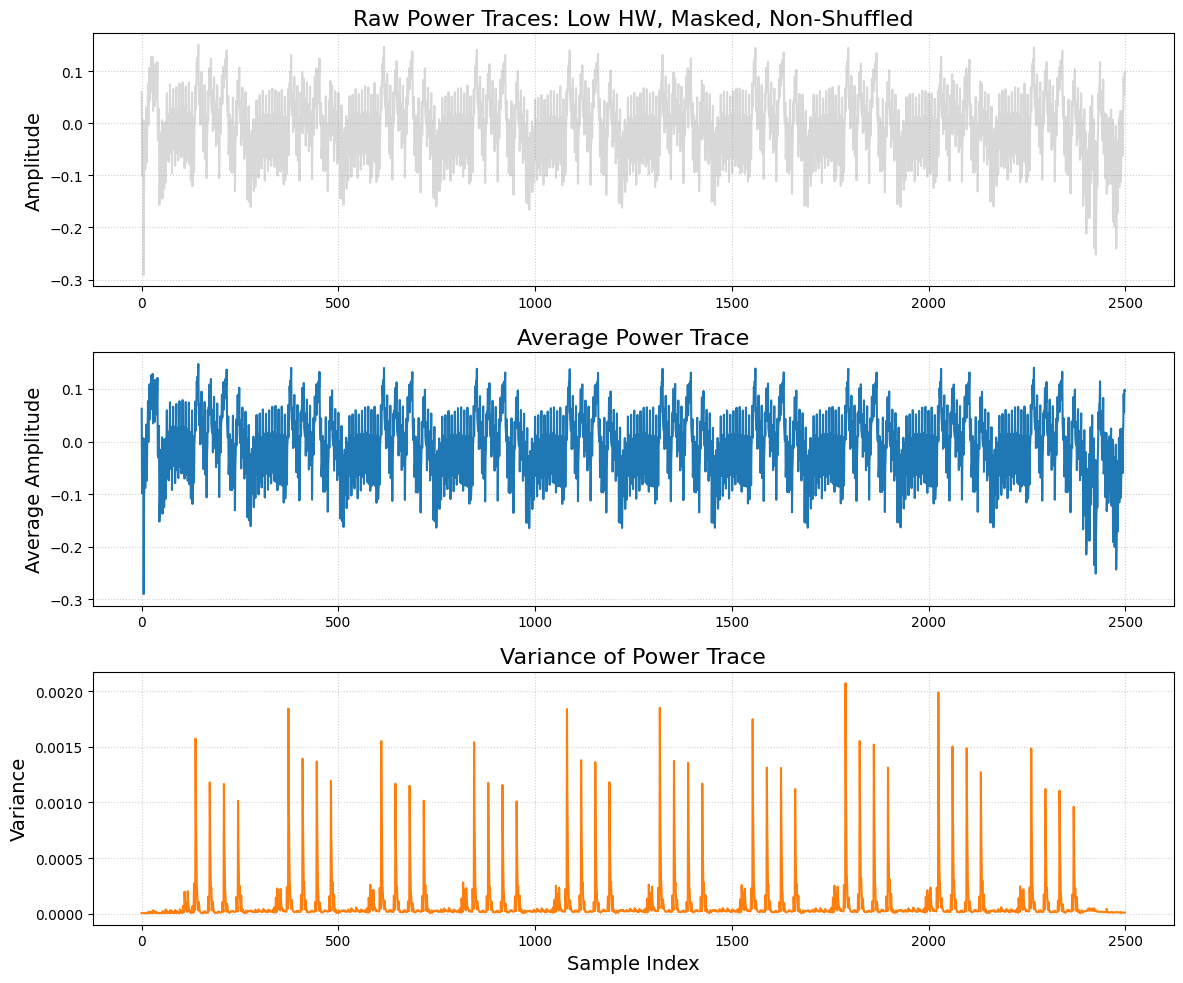

Fixed Seed: 12345678
Mode Flags Sent: 0x02
Calibrating scope sample count based on 1 step...
scope.adc.samples set to: 2500
Calibration done: 1 step took 344 cycles.
Scope samples dynamically set to 4178 (includes 20% headroom) for 10 steps.
--- Starting Leakage Assessment for Low HW, Masked, Non-Shuffled (10 steps) ---


Capturing:   0%|          | 0/1000 [00:00<?, ?it/s]

Calculating T-test statistics...


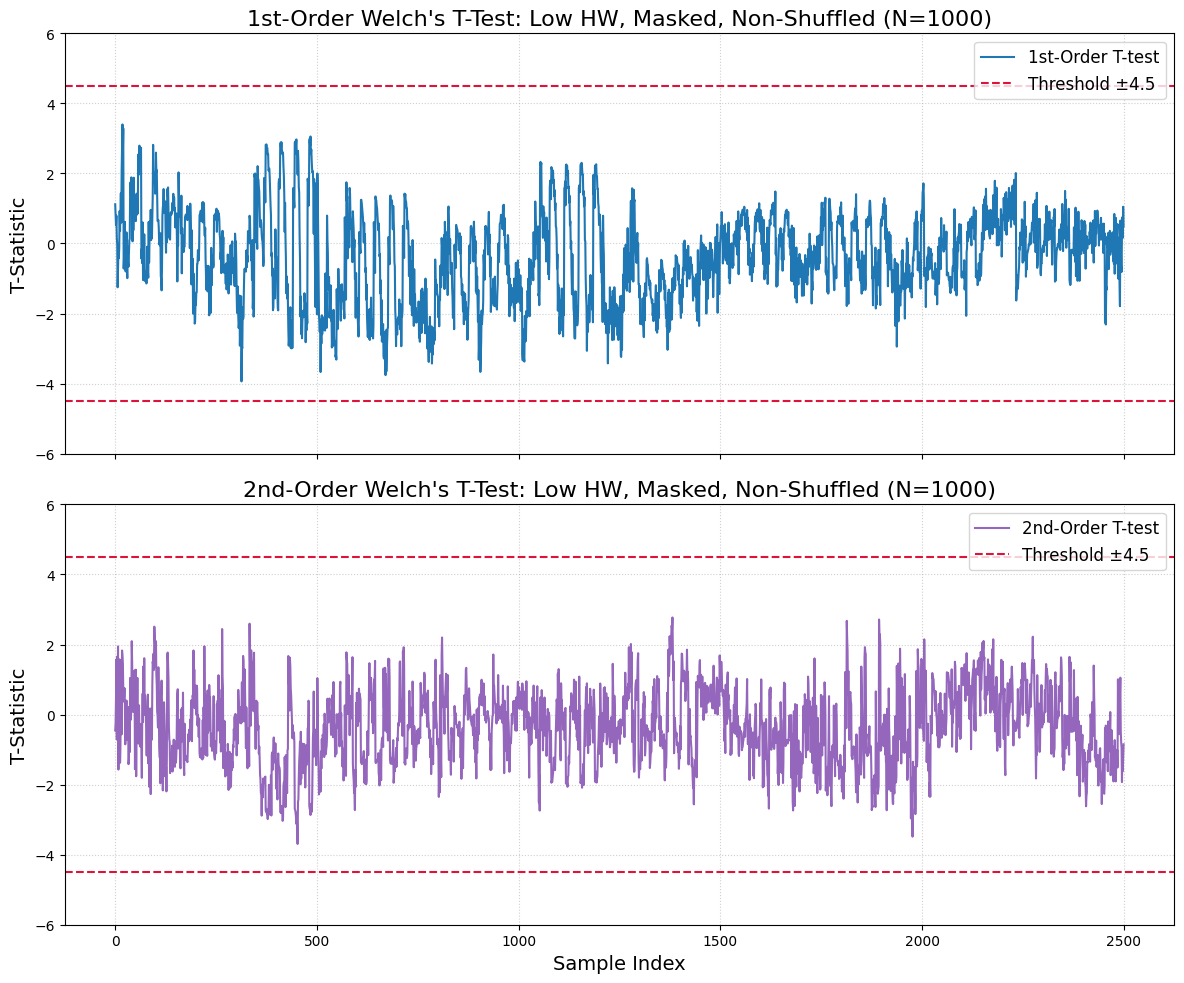

1st-Order Max Absolute T-Value: 3.9384
2nd-Order Max Absolute T-Value: 3.6940
RESULT: NO LEAKAGE DETECTED (t-values within 4.5 threshold)


In [237]:
# Executing T-test for Low Hamming Weight LFSR 
# Parameters: is_high_hw=False, num_traces=5000
config = {
    "is_high_hw": False,
    "num_steps": 10,
    "is_masked": True,
    "is_shuffled": False,
    "num_samples": 2500
}

traces, groups, label = plot_power_patterns(**config, num_traces=200)
t_values_1st, t_values_2nd, label = run_lfsr_ttest(**config, num_traces=1000)

In [232]:
save_power_traces(traces, groups, label)
save_t_test_results(t_values_1st, t_values_2nd, label)

Fixed Seed: 12345678
Mode Flags Sent: 0x07
Calibrating scope sample count based on 1 step...
Calibration done: 1 step took 436 cycles.
Scope samples dynamically set to 5282 (includes 20% headroom) for 10 steps.
--- Starting Leakage Assessment for High HW, Masked, Shuffled (10 steps) ---


Capturing:   0%|          | 0/5000 [00:00<?, ?it/s]

Calculating T-test statistics...


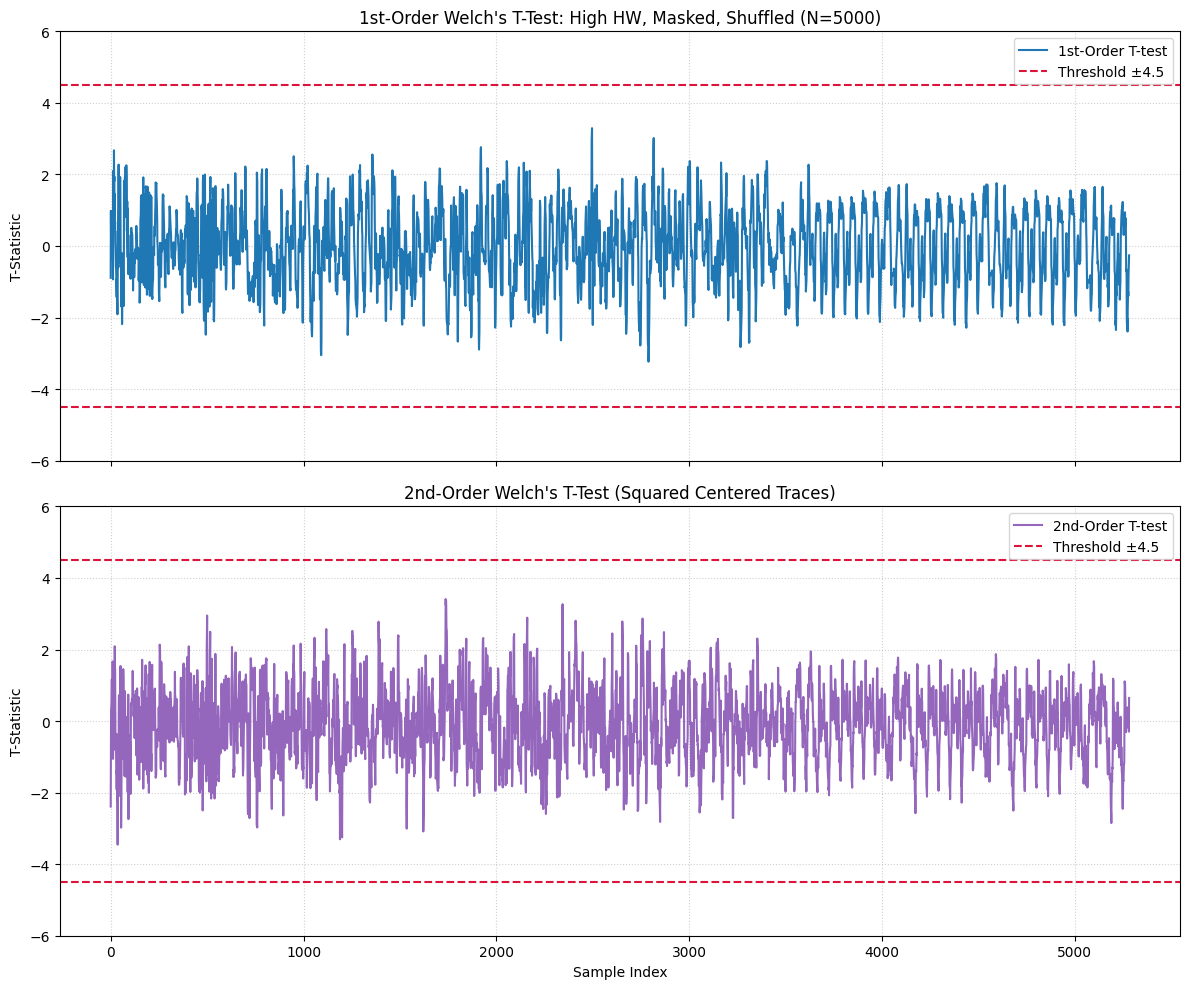

1st-Order Max Absolute T-Value: 3.2934
2nd-Order Max Absolute T-Value: 3.4529
RESULT: NO LEAKAGE DETECTED (t-values within 4.5 threshold)


In [ ]:
# Executing T-test for High Hamming Weight LFSR (Polynomial HW=15)
# Parameters: is_high_hw=True, num_traces=5000
run_lfsr_ttest(is_high_hw=True, num_traces=5000, num_steps=10, is_masked=True, is_shuffled=True)

In [ ]:
counts = []
for i in range(10):
    scope.arm()
    target.simpleserial_write('c', bytearray([1]))
    scope.capture()
    counts.append(scope.adc.trig_count)

print(f"Trig counts: {counts}")
print(f"Min: {min(counts)}, Max: {max(counts)}")

In [ ]:
# Disconnect ChipWhisperer components - very important to avoid simpleserial issues
scope.dis()
target.dis()